In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:
file_path = "Delhi_AQI_Dataset.csv"

df = pd.read_csv("/content/Delhi_AQI_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())


Dataset loaded successfully!
Rows: 2191
Columns: 11


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Unnamed: 9,Unnamed: 10
0,Delhi,01/01/18,406,223.3,438.48,336.98,462.84,4.26,385.7,NaN,NaN
1,Delhi,02/01/18,418,229.9,451.44,346.94,476.52,4.39,397.1,NaN,NaN
2,Delhi,03/01/18,382,210.1,412.56,317.06,435.48,4.01,362.9,NaN,NaN
3,Delhi,04/01/18,366,201.3,395.28,303.78,417.24,3.84,347.7,NaN,NaN
4,Delhi,05/01/18,390,214.5,421.20,323.70,444.60,4.10,370.5,NaN,NaN


In [5]:
print("Column names:")
for i, column in enumerate(df.columns):
    print(i, ":", column)


Column names:
0 : City
1 : Date
2 : AQI
3 : PM2.5
4 : PM10
5 : NO2
6 : SO2
7 : CO
8 : O3
9 : Unnamed: 9
10 : Unnamed: 10


In [6]:
print(df.info())
display(df.describe(include="all"))
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(".", "_")
)

print(df.columns.tolist())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         2191 non-null   object 
 1   Date         2191 non-null   object 
 2   AQI          2191 non-null   int64  
 3   PM2.5        2191 non-null   float64
 4   PM10         2191 non-null   float64
 5   NO2          2191 non-null   float64
 6   SO2          2191 non-null   float64
 7   CO           2191 non-null   float64
 8   O3           2191 non-null   float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  0 non-null      float64
dtypes: float64(8), int64(1), object(2)
memory usage: 188.4+ KB
None


,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,Unnamed: 9,Unnamed: 10
count,2191,2191,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,0.0,0.0
unique,1,2191,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Delhi,31/12/24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2191,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,208.285714,114.557143,224.948571,172.877143,237.445714,2.187307,197.871429,NaN,NaN
std,NaN,NaN,106.614654,58.638060,115.143827,88.490163,121.540706,1.119494,101.283922,NaN,NaN
min,NaN,NaN,41.000000,22.550000,44.280000,34.030000,46.740000,0.430000,38.950000,NaN,NaN
25%,NaN,NaN,117.000000,64.350000,126.360000,97.110000,133.380000,1.230000,111.150000,NaN,NaN
50%,NaN,NaN,190.000000,104.500000,205.200000,157.700000,216.600000,2.000000,180.500000,NaN,NaN
75%,NaN,NaN,289.000000,158.950000,312.120000,239.870000,329.460000,3.030000,274.550000,NaN,NaN


['City', 'Date', 'AQI', 'PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Unnamed:_9', 'Unnamed:_10']


In [7]:
print("Available columns:")
print(df.columns.tolist())

# Find AQI column
aqi_candidates = [
    col for col in df.columns
    if "AQI" in col.upper()
]

print("\nPossible AQI columns:")
print(aqi_candidates)


Available columns:
['City', 'Date', 'AQI', 'PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Unnamed:_9', 'Unnamed:_10']

Possible AQI columns:
['AQI']


In [8]:
target = "AQI"

if target not in df.columns:
    raise ValueError(
        f"AQI column not found. Available columns are: {df.columns.tolist()}"
    )

print("Target column:", target)


Target column: AQI


In [10]:
possible_features = [
    "PM2_5",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

features = [
    column for column in possible_features
    if column in df.columns
]

print("Features found:")
print(features)


Features found:
['PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']


In [11]:
print("Missing values:")

missing = df[features + [target]].isnull().sum()

print(missing)


Missing values:
PM2_5    0
PM10     0
NO2      0
SO2      0
CO       0
O3       0
AQI      0
dtype: int64


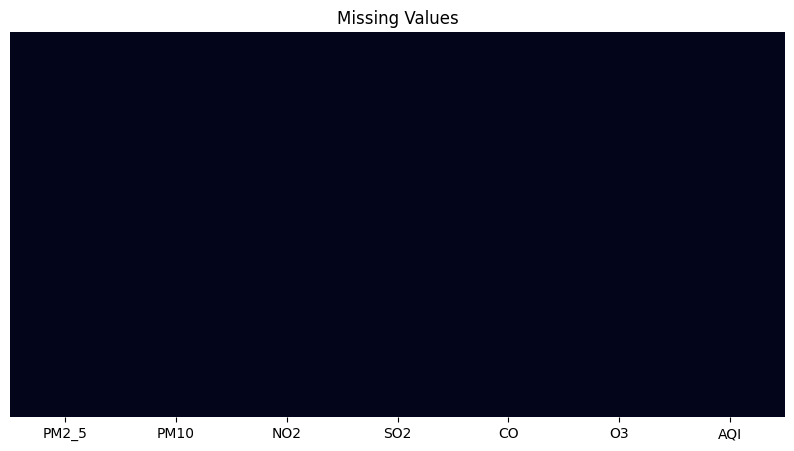

In [12]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df[features + [target]].isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()


In [13]:
for column in features + [target]:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print(df[features + [target]].dtypes)


PM2_5    float64
PM10     float64
NO2      float64
SO2      float64
CO       float64
O3       float64
AQI        int64
dtype: object


In [14]:
before = len(df)

df = df.dropna(
    subset=features + [target]
)

after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)


Rows before cleaning: 2191
Rows after cleaning: 2191
Rows removed: 0


In [15]:
df = df[df[target] >= 0]

for feature in features:
    df = df[df[feature] >= 0]

print("Final dataset shape:", df.shape)


Final dataset shape: (2191, 11)


In [16]:
display(df[features + [target]].describe())


,PM2_5,PM10,NO2,SO2,CO,O3,AQI
count,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000,2191.000000
mean,114.557143,224.948571,172.877143,237.445714,2.187307,197.871429,208.285714
std,58.638060,115.143827,88.490163,121.540706,1.119494,101.283922,106.614654
min,22.550000,44.280000,34.030000,46.740000,0.430000,38.950000,41.000000
25%,64.350000,126.360000,97.110000,133.380000,1.230000,111.150000,117.000000
50%,104.500000,205.200000,157.700000,216.600000,2.000000,180.500000,190.000000
75%,158.950000,312.120000,239.870000,329.460000,3.030000,274.550000,289.000000
max,271.700000,533.520000,410.020000,563.160000,5.190000,469.300000,494.000000


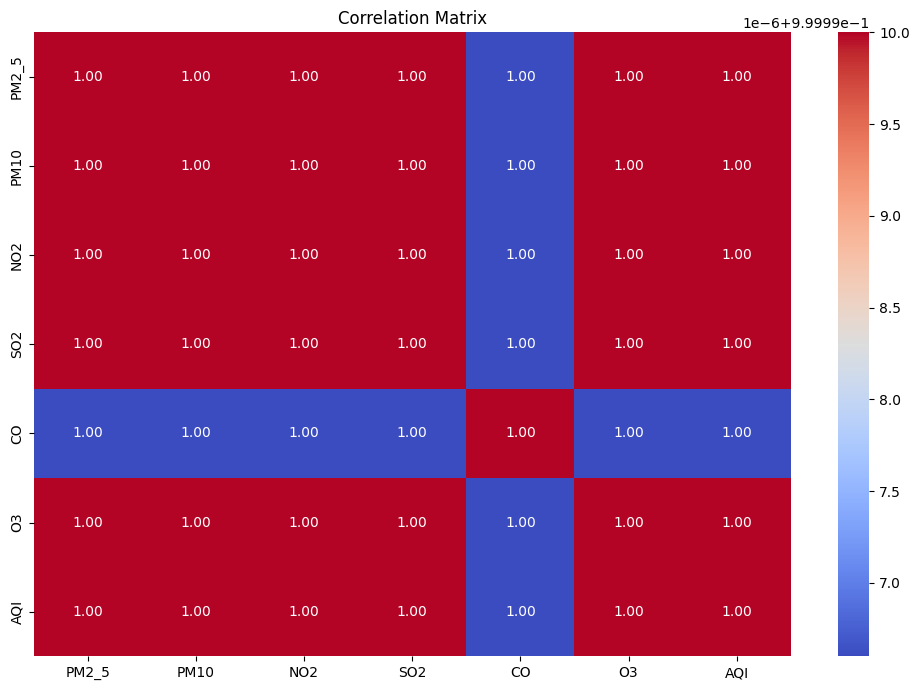

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[features + [target]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


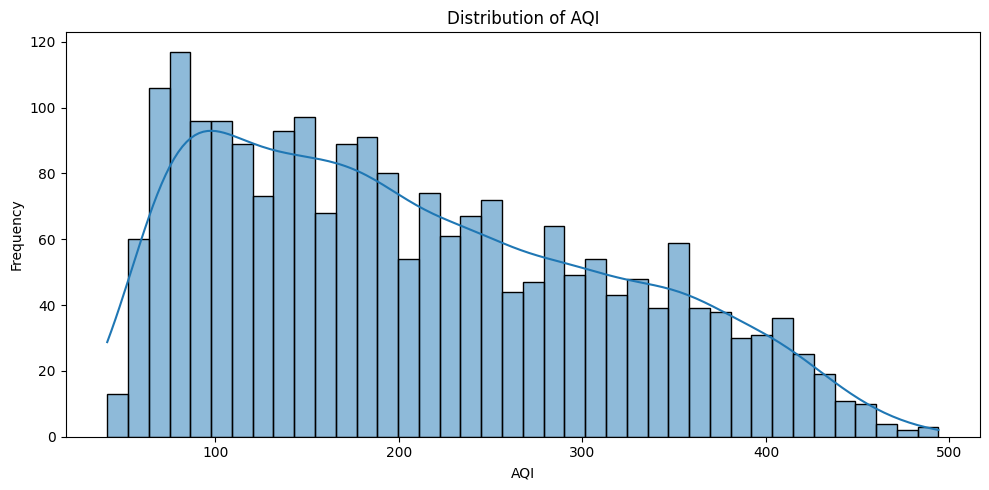

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[target],
    bins=40,
    kde=True
)

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [19]:
X = df[features]

y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2191, 6)
y shape: (2191,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 1752
Testing samples: 439


In [21]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_prediction = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_prediction
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_prediction
    )
)

linear_r2 = r2_score(
    y_test,
    linear_prediction
)

print("Linear Regression")
print("-------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))


Linear Regression
-------------------------
MAE : 0.0
RMSE: 0.0
R²  : 1.0


In [22]:
tree_model = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_prediction = tree_model.predict(
    X_test
)

tree_mae = mean_absolute_error(
    y_test,
    tree_prediction
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_prediction
    )
)

tree_r2 = r2_score(
    y_test,
    tree_prediction
)

print("Decision Tree")
print("-------------------------")
print("MAE :", round(tree_mae, 2))
print("RMSE:", round(tree_rmse, 2))
print("R²  :", round(tree_r2, 4))


Decision Tree
-------------------------
MAE : 0.03
RMSE: 0.17
R²  : 1.0


In [23]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Training completed!")


Training Random Forest...
Training completed!


In [25]:
rf_prediction = rf_model.predict(
    X_test
)


In [26]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("Random Forest")
print("-------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))


Random Forest
-------------------------
MAE : 0.04
RMSE: 0.12
R²  : 1.0


In [27]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

display(
    results.round(4)
)


,Model,MAE,RMSE,R2
0,Linear Regression,0.0000,0.0000,1.0
1,Decision Tree,0.0273,0.1653,1.0
2,Random Forest,0.0379,0.1153,1.0


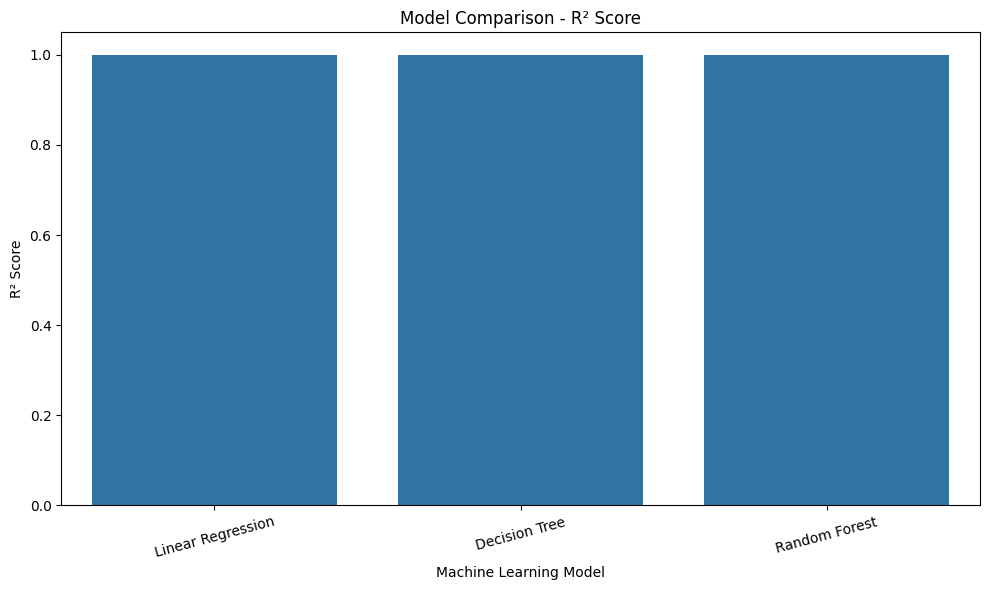

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xlabel("Machine Learning Model")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


In [29]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance)


,Feature,Importance
4,CO,0.183017
0,PM2_5,0.178806
5,O3,0.175291
1,PM10,0.163481
3,SO2,0.158535
2,NO2,0.140870


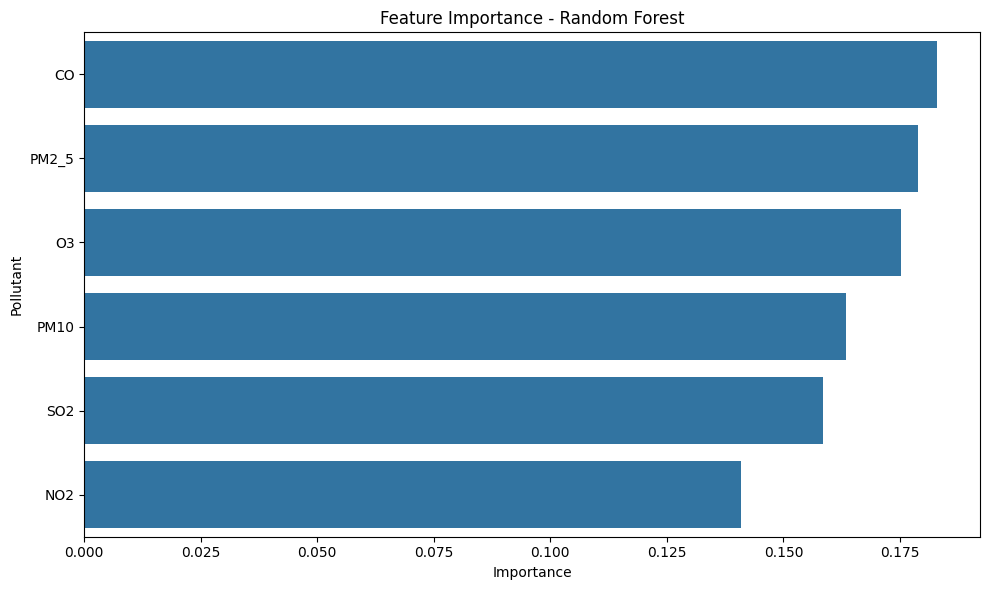

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Pollutant")

plt.tight_layout()

plt.show()


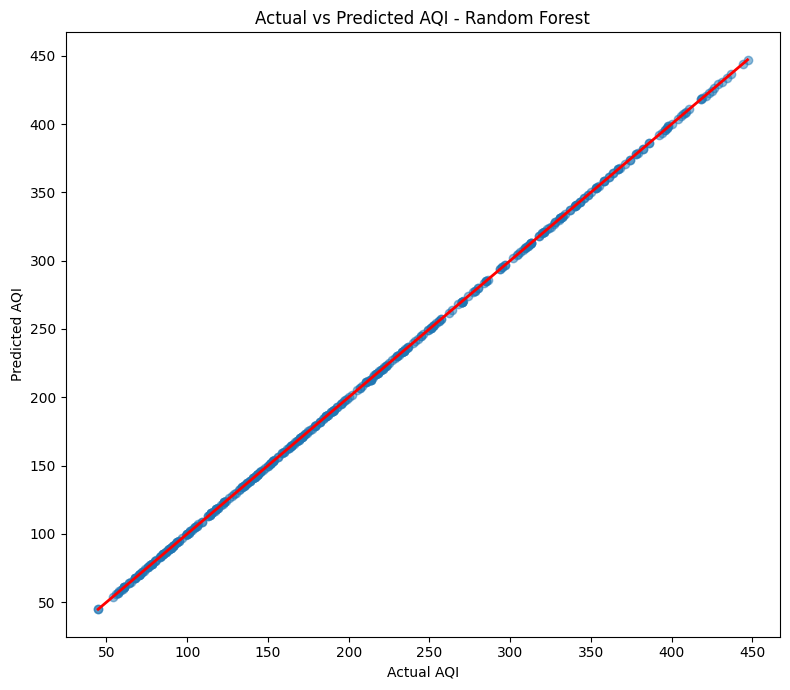

In [31]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    rf_prediction,
    alpha=0.5
)

minimum = min(
    y_test.min(),
    rf_prediction.min()
)

maximum = max(
    y_test.max(),
    rf_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linewidth=2
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title(
    "Actual vs Predicted AQI - Random Forest"
)

plt.tight_layout()

plt.show()


In [32]:
model_data = {
    "model": rf_model,
    "features": features
}

joblib.dump(
    model_data,
    "delhi_aqi_model.pkl"
)

print("Model saved successfully!")
print("File: delhi_aqi_model.pkl")


Model saved successfully!
File: delhi_aqi_model.pkl


In [33]:
# Load model
saved_data = joblib.load(
    "delhi_aqi_model.pkl"
)

model = saved_data["model"]
model_features = saved_data["features"]

print("Model features:")
print(model_features)


Model features:
['PM2_5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']


In [34]:
pm25 = float(input("Enter PM2.5: "))
pm10 = float(input("Enter PM10: "))
no2 = float(input("Enter NO2: "))
so2 = float(input("Enter SO2: "))
co = float(input("Enter CO: "))
o3 = float(input("Enter O3: "))

new_data = pd.DataFrame({
    "PM2_5": [pm25],
    "PM10": [pm10],
    "NO2": [no2],
    "SO2": [so2],
    "CO": [co],
    "O3": [o3]
})

# Keep only features used by model
new_data = new_data[model_features]

predicted_aqi = model.predict(
    new_data
)[0]

print("\nPredicted AQI:", round(predicted_aqi, 2))


Enter PM2.5: 45
Enter PM10: 67
Enter NO2: 23
Enter SO2: 43
Enter CO: 34
Enter O3: 67

Predicted AQI: 119.21


In [35]:
def get_aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


category = get_aqi_category(
    predicted_aqi
)

print("AQI Category:", category)


AQI Category: Moderate
